# Dennler Odor not_PCA

In [1]:
# from lib import epl as EPL 
# from lib import OSN
# from lib import readout
from lib import plots
import matplotlib.pyplot as plt
from preprocess import preprocessing as pre
import time
import numpy as np
import pickle 

from Dennler_lib.epl import EPL 
from Dennler_lib.OSN import OSN_encoding
from Dennler_lib.readout import readout
#from Dennler_lib import plots
from my_lib import my_plots
from my_lib import my_readout

trainingOdors, testOdors = np.load('multiOdorTest.npy', fix_imports=True, allow_pickle=True); 

## Hashtable Classifier

Number of odors to train: 10
Number of odors to test: 100
Training Duration total: 0.0 s
Testing Duration total: 0.18851566314697266 s
(500, 10)


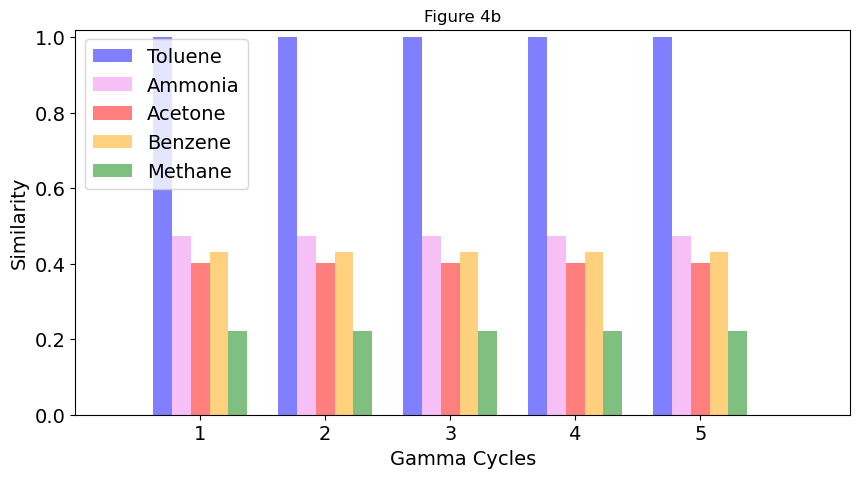

In [2]:
import numpy as np
import time

class HashTableClassifier():
    def train(self, training_data):
        self.learned_odour_representations = {idx: odour for idx, odour in enumerate(training_data)}

    def denoise_test(self, testing_data):
        self.denoised_testing_data = {}
        for idx_test, testing_odour in enumerate(testing_data):
            best_matching, idx_best_matching = 0, None
            for idx_train, training_odour in self.learned_odour_representations.items():
                matches = sum(training_odour == testing_odour)
                if best_matching < matches:
                    best_matching, idx_best_matching = matches, idx_train
            self.denoised_testing_data[idx_test] = self.learned_odour_representations[idx_best_matching]

    def get_similarity_matrix(self):
        sMatrix = np.zeros((len(self.denoised_testing_data) * 5, len(self.learned_odour_representations)))
        for idx_test, testing_odour in self.denoised_testing_data.items():
            for idx_train, training_odour in self.learned_odour_representations.items():
                similarity = np.count_nonzero(training_odour == testing_odour) / 72
                for i in range(5):
                    sMatrix[5 * idx_test + i, idx_train] = similarity
        return sMatrix


def run_from_arrays(trainingOdors, testOdors):
    nOdors = len(trainingOdors)
    nTestPerOdor = len(testOdors) / nOdors
    print("Number of odors to train:", len(trainingOdors))
    print("Number of odors to test:", len(testOdors))

    # Initiate classifier
    hashtable_classifier = HashTableClassifier()

    # Run training
    t0 = time.time()
    hashtable_classifier.train(trainingOdors)
    t1 = time.time()

    # Run testing
    hashtable_classifier.denoise_test(testOdors)
    t2 = time.time()

    train_time = t1 - t0
    test_time = t2 - t1

    print("Training Duration total:", train_time, "s")
    print("Testing Duration total:", test_time, "s")

    # Extract similarity matrix
    sMatrix = hashtable_classifier.get_similarity_matrix()
    return sMatrix, hashtable_classifier.denoised_testing_data

sMatrix, denoised_data = run_from_arrays(trainingOdors, testOdors)
print(sMatrix.shape)  # Check the shape of the similarity matrix
plots.plotFigure4b(sMatrix); 

In [3]:
nOdors = len(trainingOdors); 
nGammaPerOdor = 5
nTestPerOdor = len(testOdors)/nOdors;  
print("Number of odors to train = " + str(len(trainingOdors))); 
print("Number of odors to test = " + str(len(testOdors))); 

#Network initialization
nMCs = len(trainingOdors[0]); 
GCsPerNeurogenesis = 5; 
nGCs = nMCs*GCsPerNeurogenesis*nOdors;     #every MC has 5 GCs per odor  
epl = EPL(nMCs, nGCs, GCsPerNeurogenesis); 

#Sniff
def sniff(odor, learn_flag=0, nGammaPerOdor=5, gPeriod=40):
    sensorInput = OSN_encoding(odor); 
    for j in range(0, nGammaPerOdor):
        for k in range(0, gPeriod): 
            epl.update(sensorInput, learn_flag=learn_flag);
            pass; 
    epl.reset(); 

#Training (Mine)
t1 = time.time(); 
for i in range(0, len(trainingOdors)):
    print("Training odor " + str(i+1)) 
    sniff(trainingOdors[i], learn_flag=1,nGammaPerOdor = nGammaPerOdor); #nGammaPerOdor_training = 10 define early in code
    # changed nGammaPerOdor from 5 to 10
    epl.GClayer.invokeNeurogenesis();
#added this for loop to change structure of epl.gammaCode
for i in range(0, len(trainingOdors)):
    sniff(trainingOdors[i], learn_flag=0, nGammaPerOdor = nGammaPerOdor);
    
# #Training (Dennler's)
# t0 = time.time() 
# for i in range(0, len(trainingOdors)):
#     # print("Training odor " + str(i+1)) 
#     sniff(trainingOdors[i], learn_flag=1)
#     epl.GClayer.invokeNeurogenesis()
#     sniff(trainingOdors[i], learn_flag=0)
# t1 = time.time()

#Testing
for i in range(0, len(testOdors)):
    sniff(testOdors[i], learn_flag=0, nGammaPerOdor = nGammaPerOdor); 
    # if((i+1)%10==0 and (i+1)!=0):
    #     print(str(i+1) + " odors tested"); 
t2 = time.time(); 
print("Simulation Duration = " + str(t2-t1) + "s")

#Readout (Mine)
from my_lib import my_readout
sMatrix = my_readout.readout(epl.gammaCode, nOdors, nTestPerOdor)  
# #Readout (Dennler's)
# sMatrix = readout(epl.gammaCode, nOdors, nTestPerOdor)  


Number of odors to train = 10
Number of odors to test = 100
Training odor 1
Training odor 2
Training odor 3
Training odor 4
Training odor 5
Training odor 6
Training odor 7
Training odor 8
Training odor 9
Training odor 10
Simulation Duration = 1059.1918668746948s


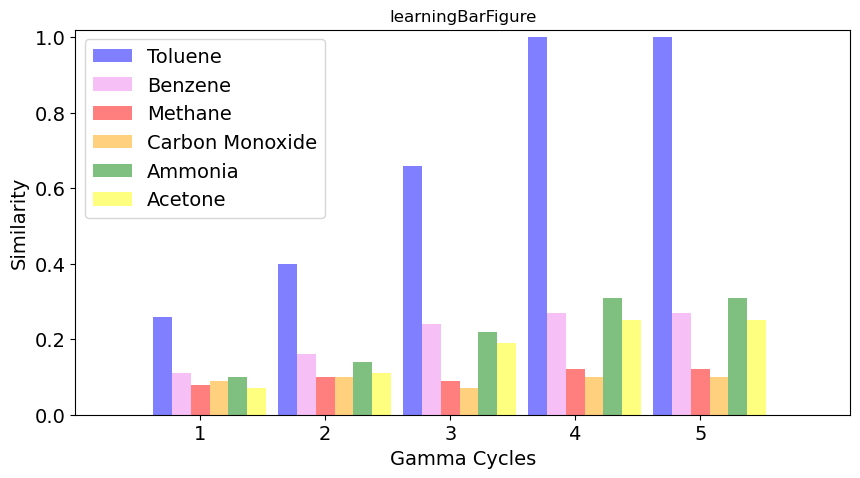

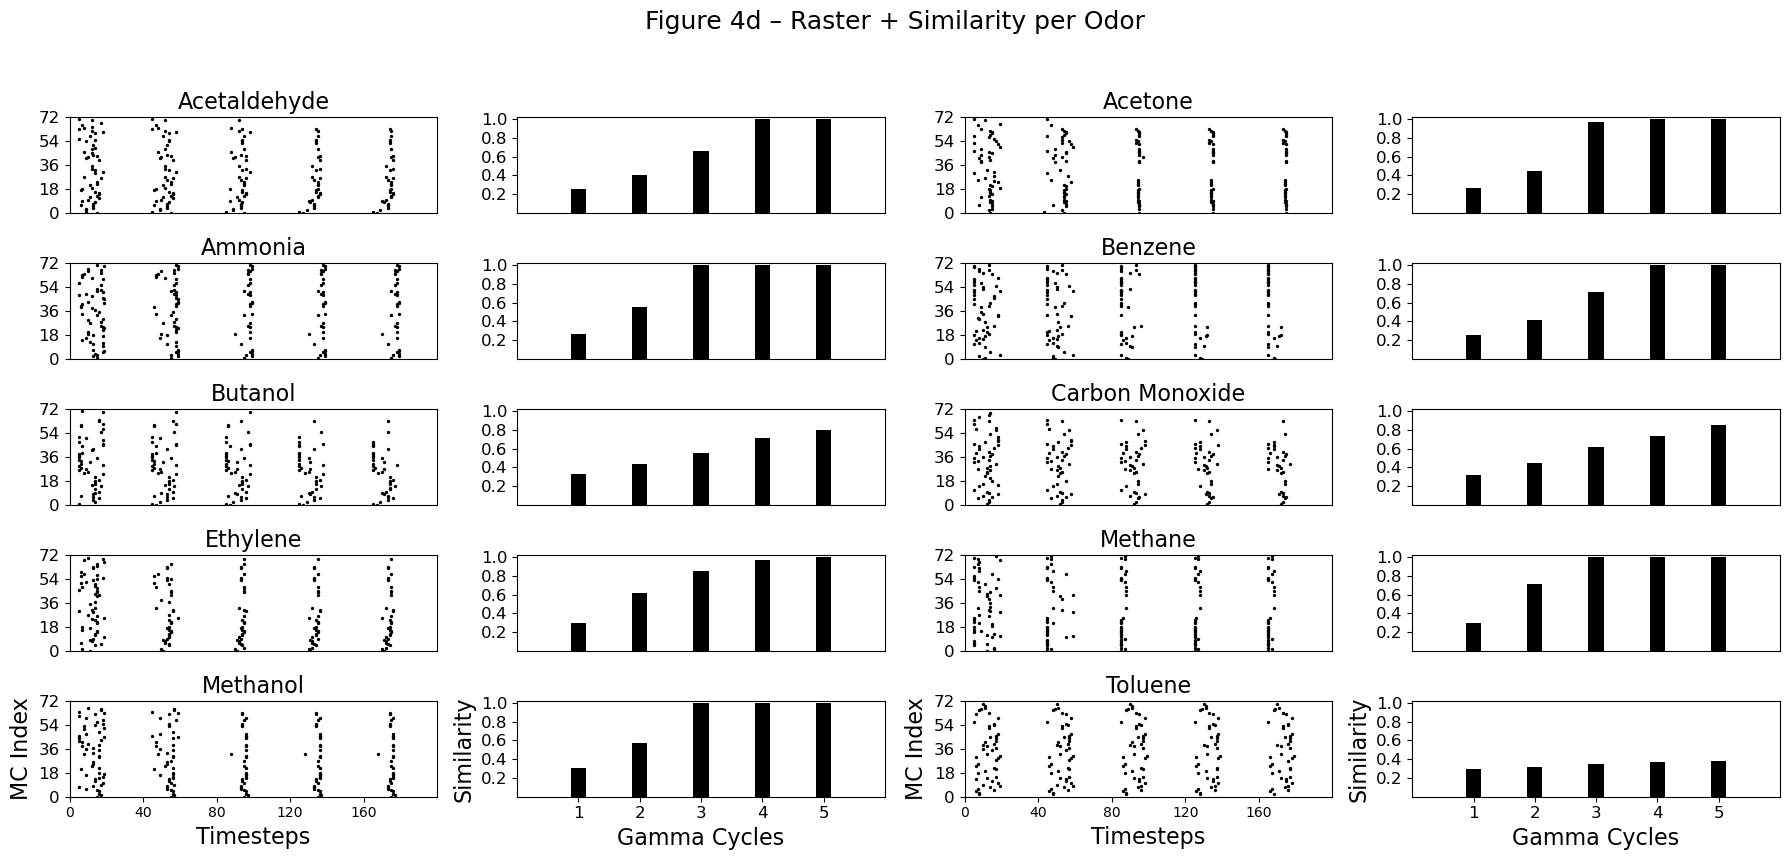

In [4]:
#pre.my_plotFigure3b(epl.gammaCode, 1, nMCs, nGamma = nGammaPerOdor)
from my_lib import my_plots
plotTitles = ['Toluene', 'Benzene', 'Methane', 'Carbon Monoxide', 'Ammonia', 'Acetone', 'Acetaldehyde','Methanol','Butanol','Ethylene']
my_plots.learningBarFigure(sMatrix, plotTitles)
plotTitles = ['Acetaldehyde', 'Acetone', 'Ammonia', 'Benzene', 'Butanol', 'Carbon Monoxide', 'Ethylene', 'Methane', 'Methanol', 'Toluene'];
my_plots.rasterSimilarityPlot(epl.gammaCode, sMatrix, plotTitles, nMCs = epl.nMCs, nGamma = 5)

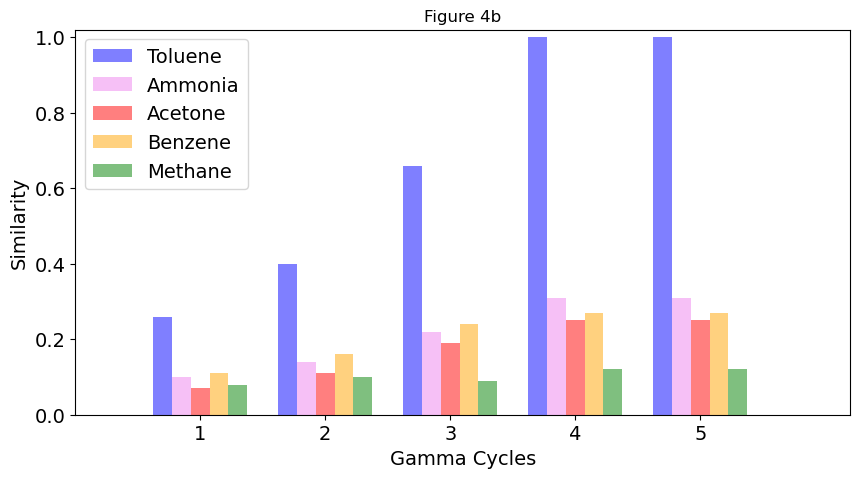

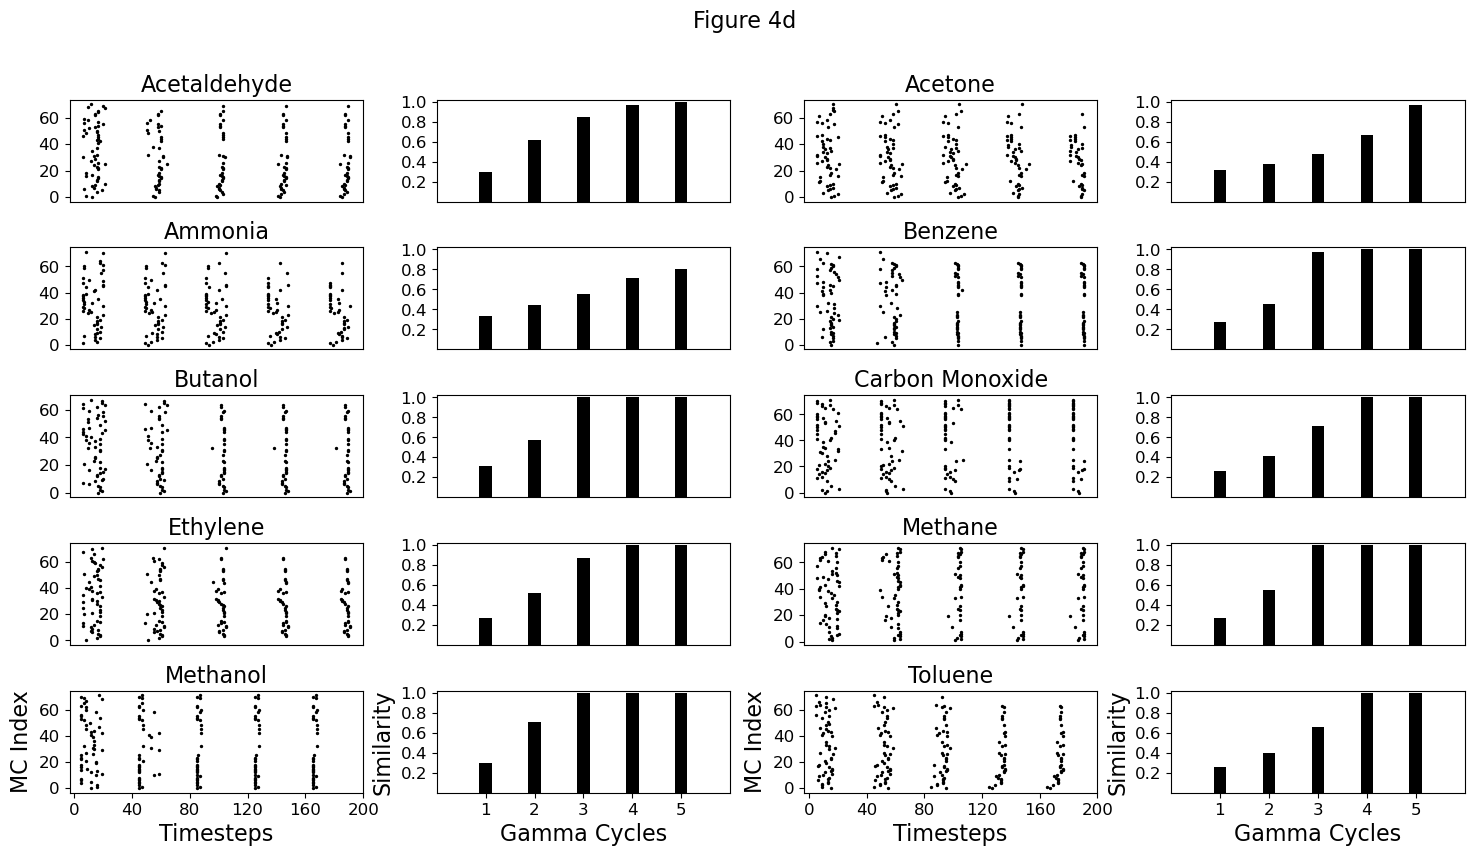

In [5]:
#Plots
#plots.plotFigure4a(epl.gammaCode, nMCs = nMCs)#, nGamma = nGammaPerOdor)
plots.plotFigure4b(sMatrix); 
plots.plotFigure4d(epl.gammaCode, sMatrix); 

from my_lib import my_readout
sMatrix = my_readout.readout(epl.gammaCode, nOdors, nTestPerOdor)  
plotTitles = ['Acetaldehyde', 'Acetone', 'Ammonia', 'Benzene', 'Butanol', 'Carbon Monoxide', 'Ethylene', 'Methane', 'Methanol', 'Toluene'];my_plots.learningBarFigure(sMatrix, plotTitles)
my_plots.rasterSimilarityPlot(epl.gammaCode, sMatrix, plotTitles, nMCs = epl.nMCs, nOdors = nOdors, nGamma = 5)

# plotFigure3b = gammaLearning (good name?)
"Odourant-evoked MC activity patterns are attracted to learned representations"

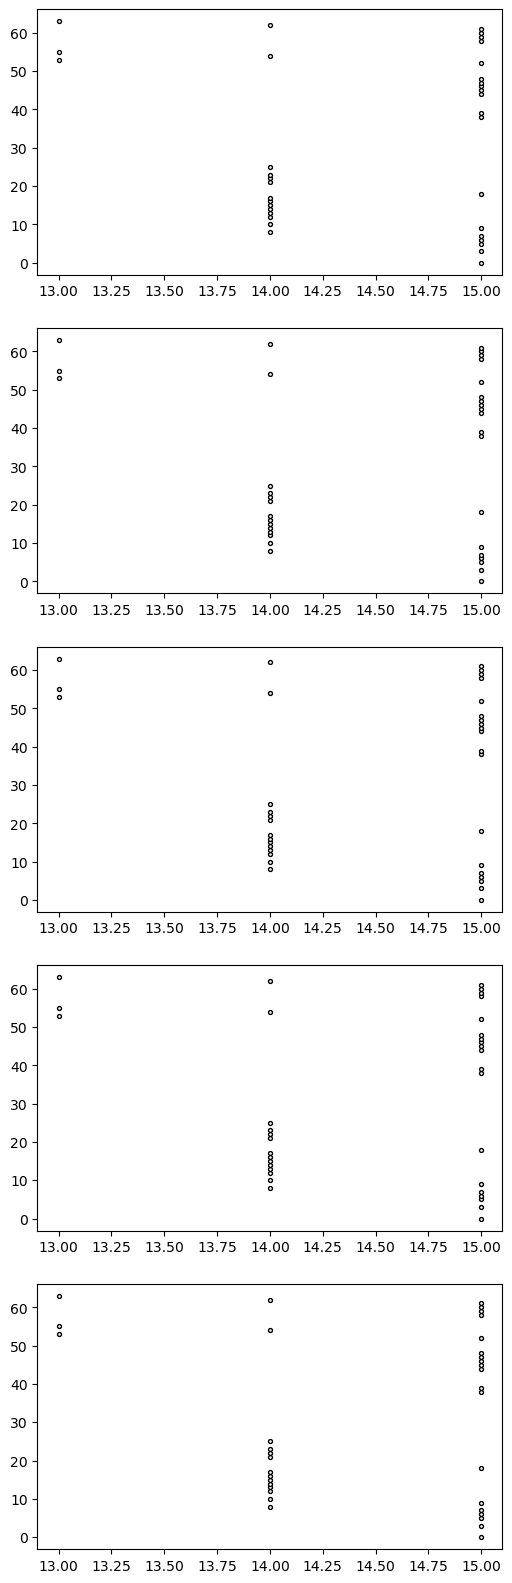

In [6]:
pre.my_plotFigure3b(epl.gammaCode, 1, nMCs, nGamma = nGammaPerOdor)


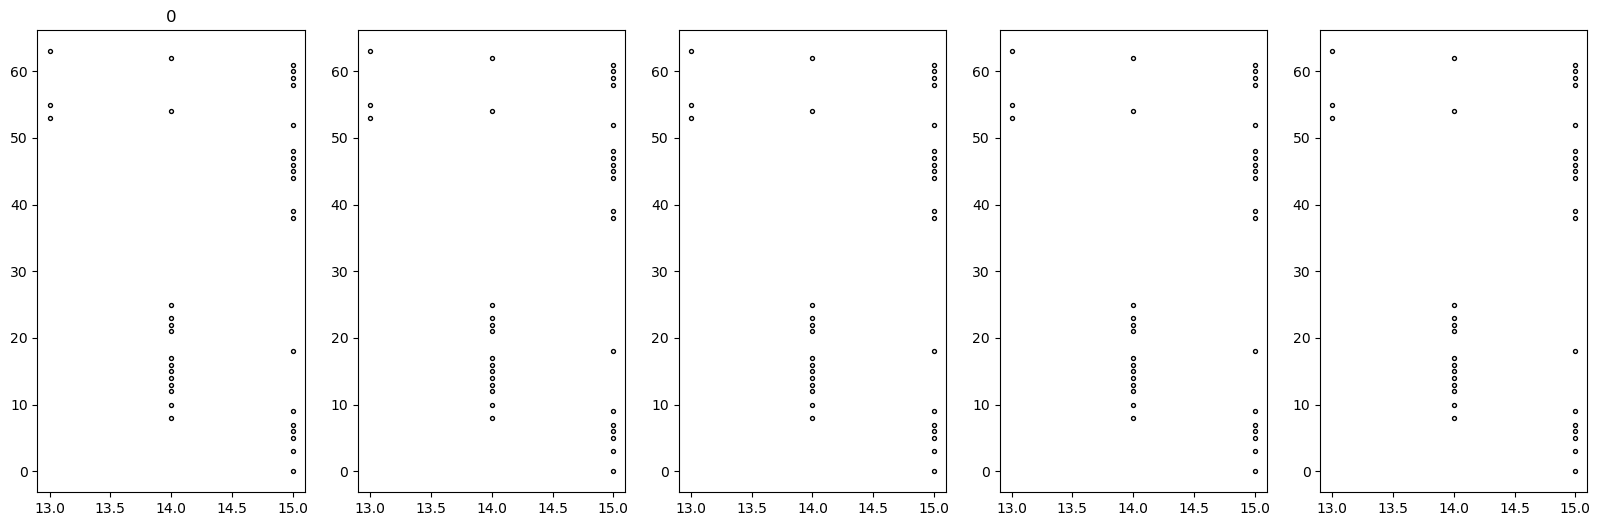

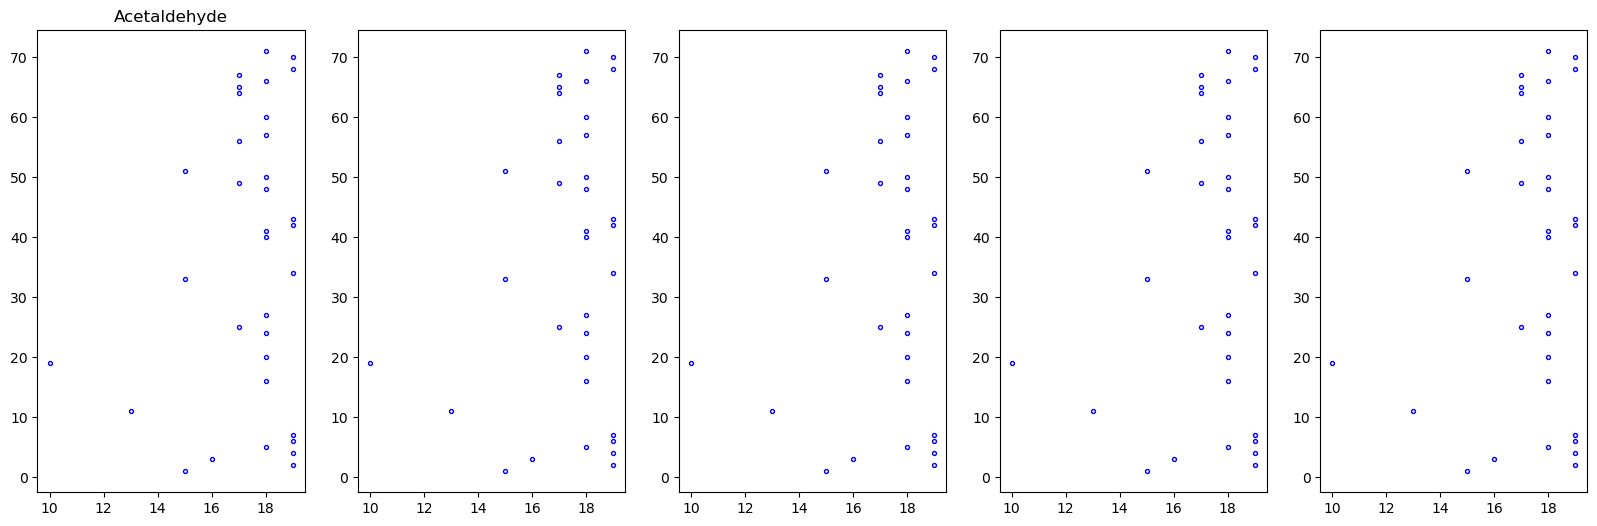

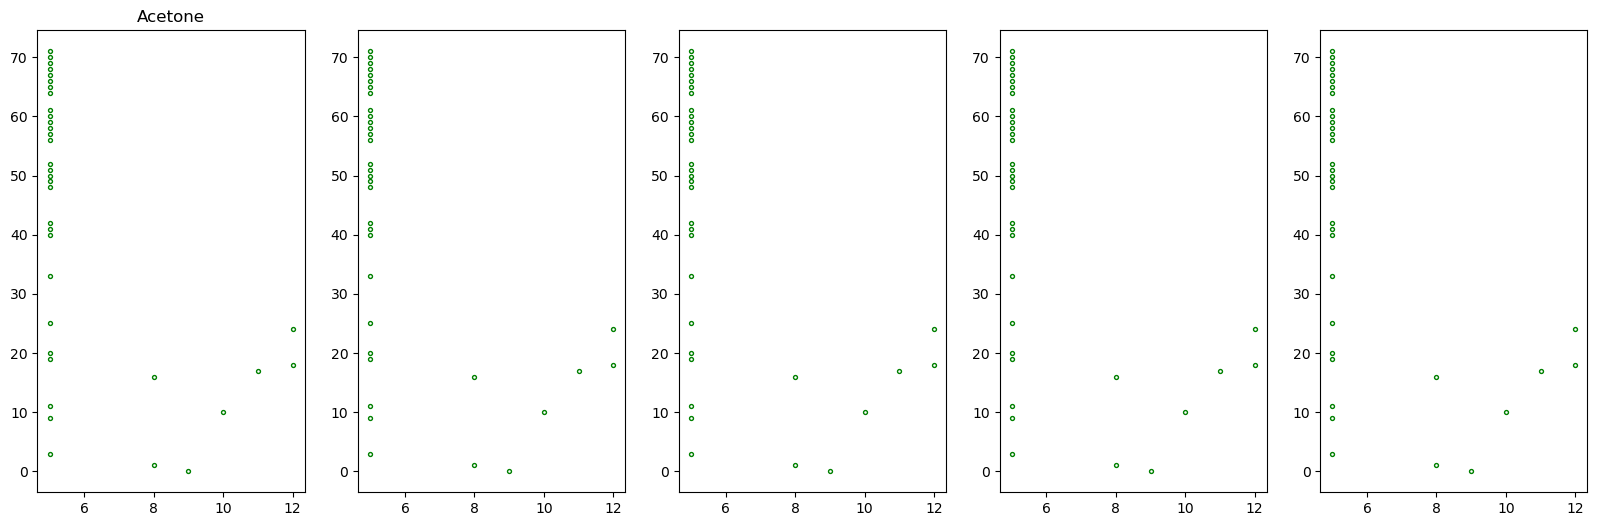

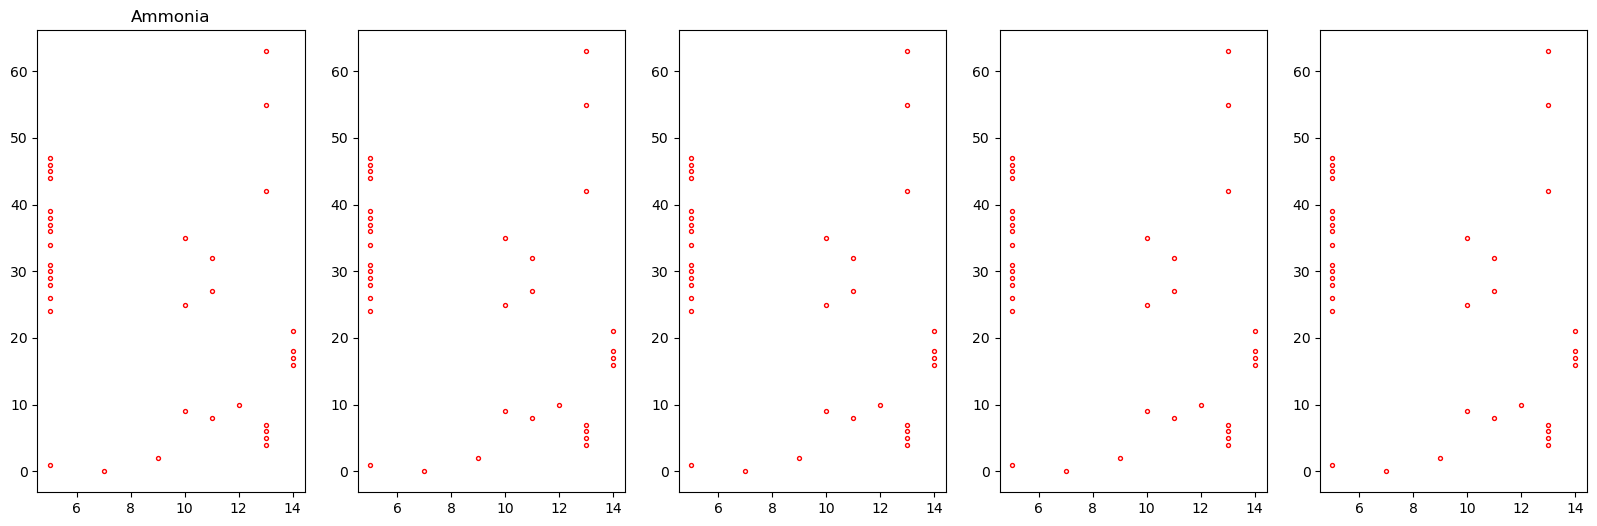

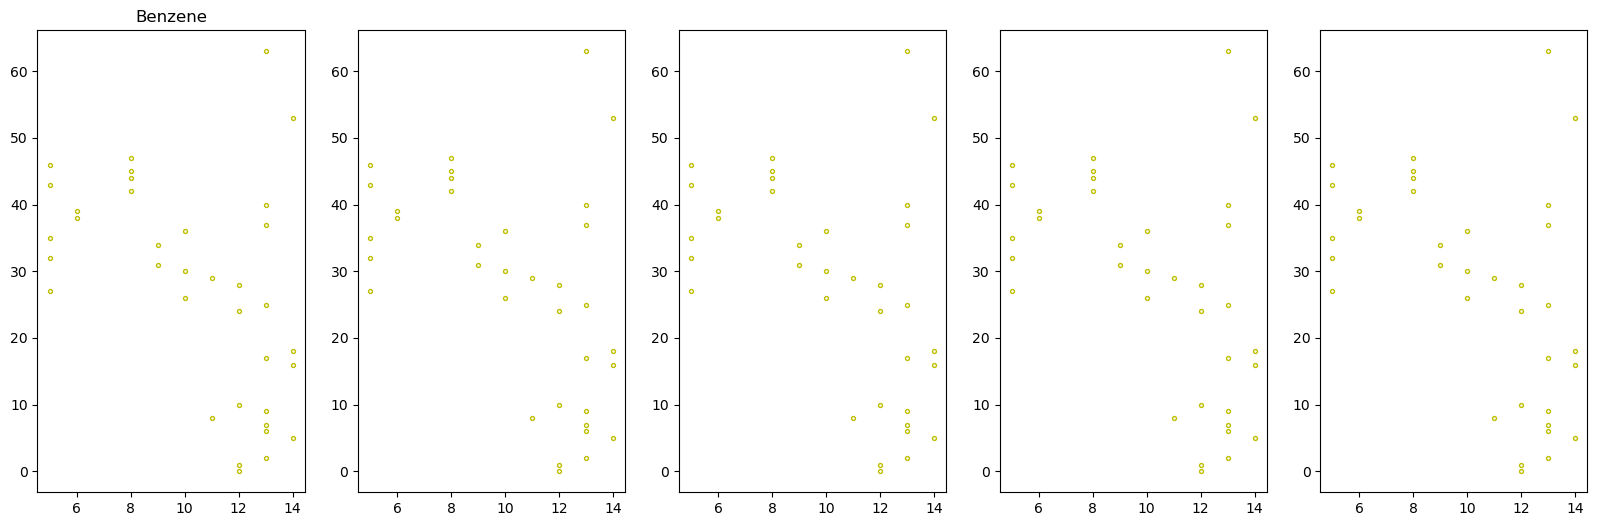

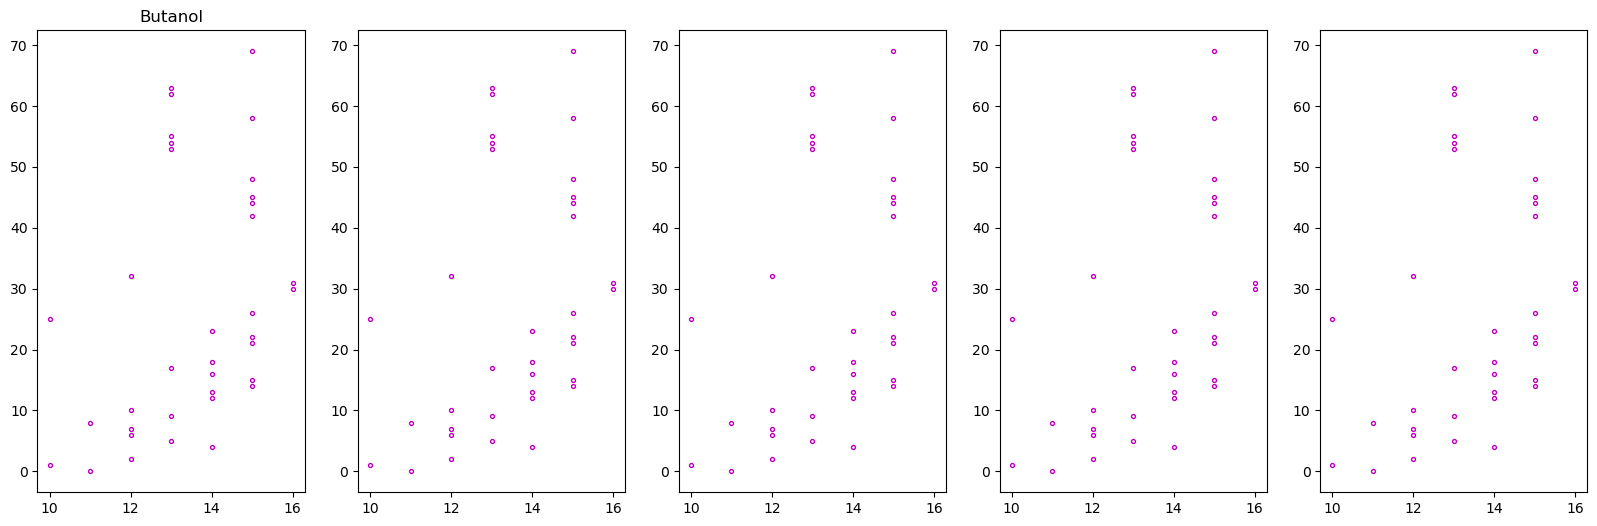

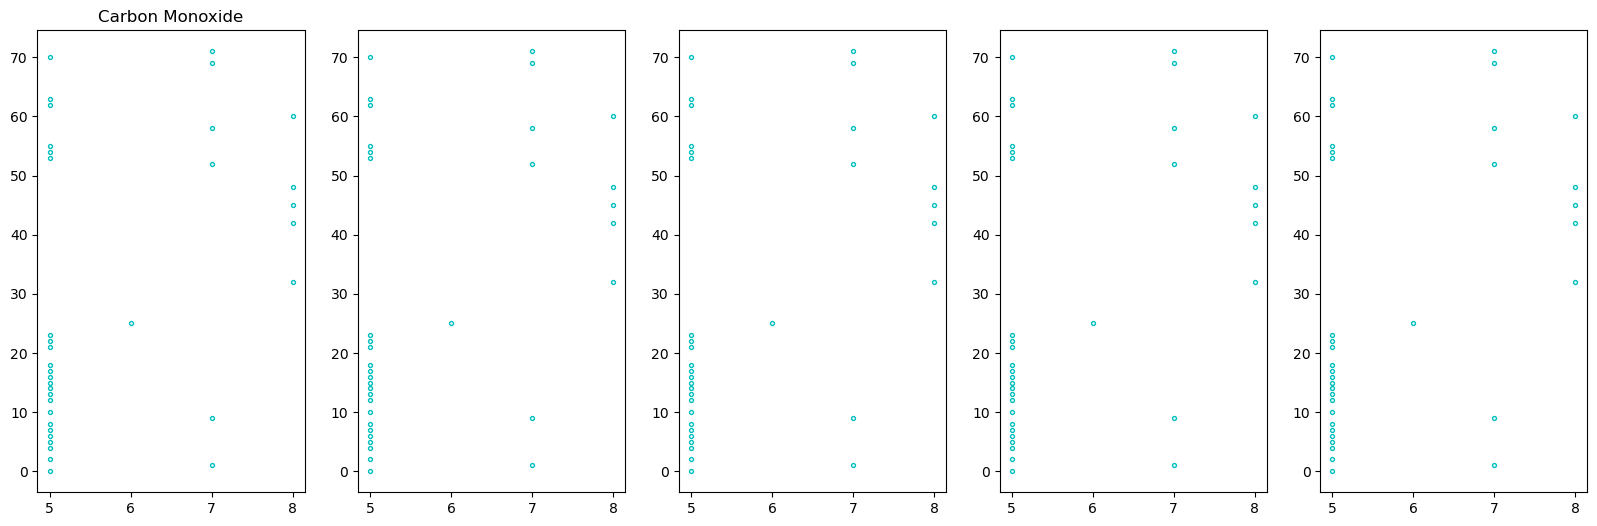

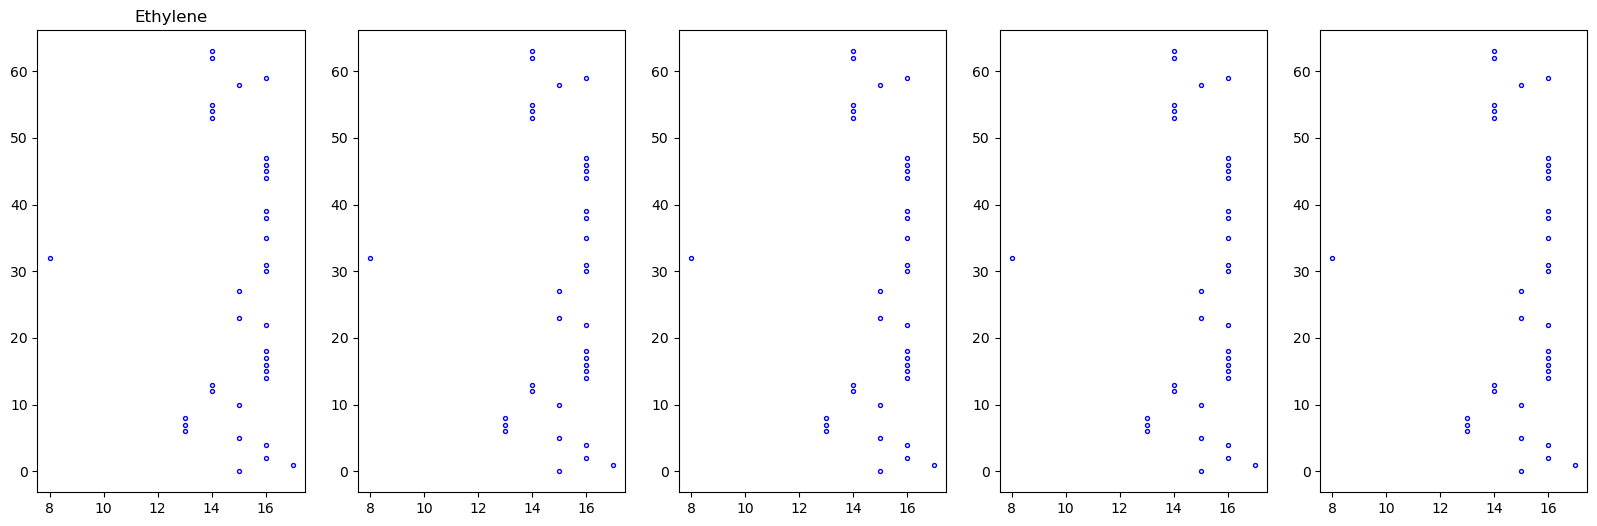

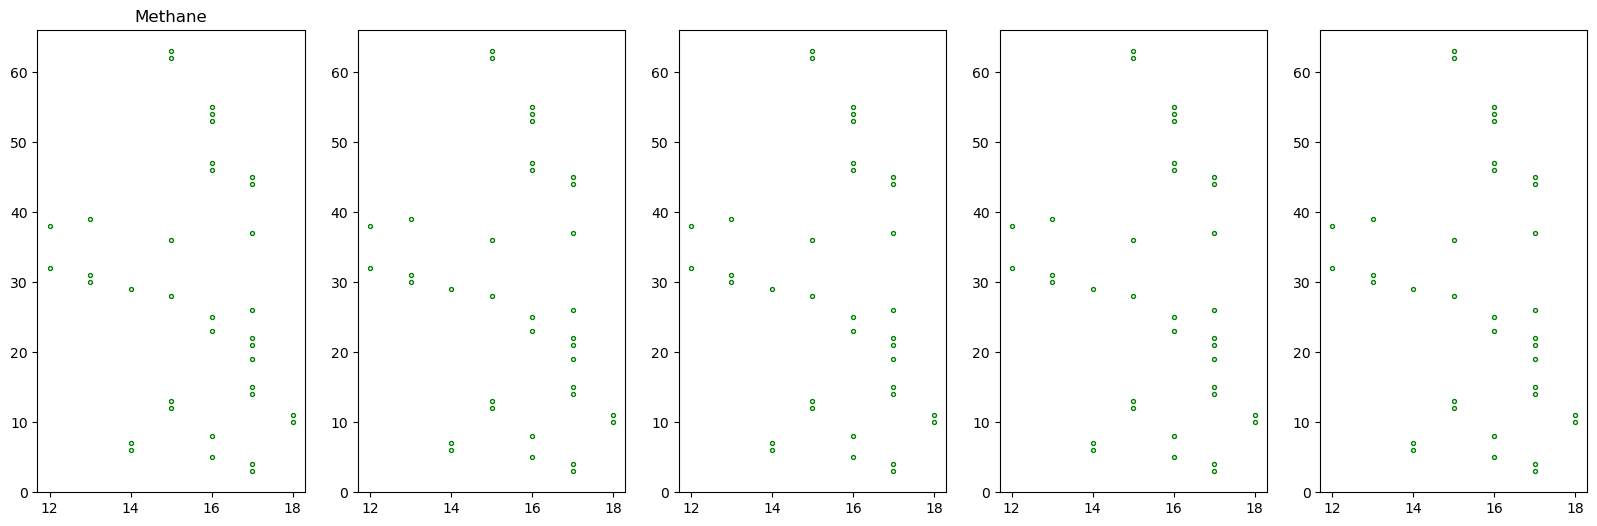

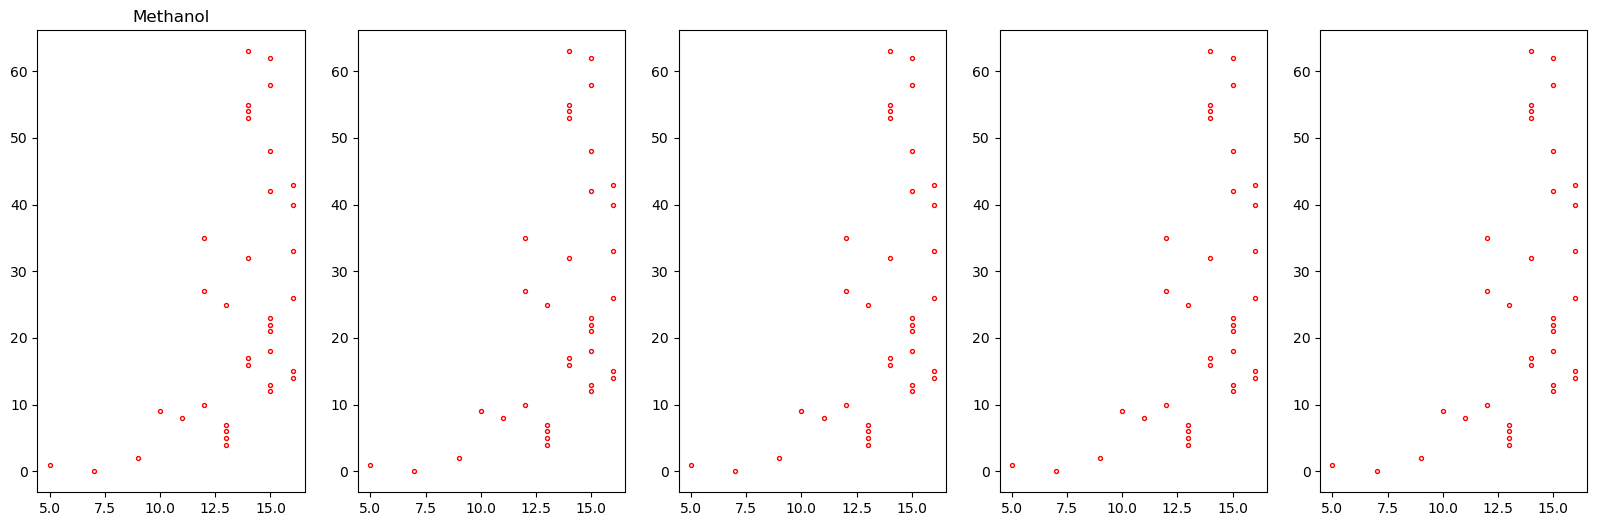

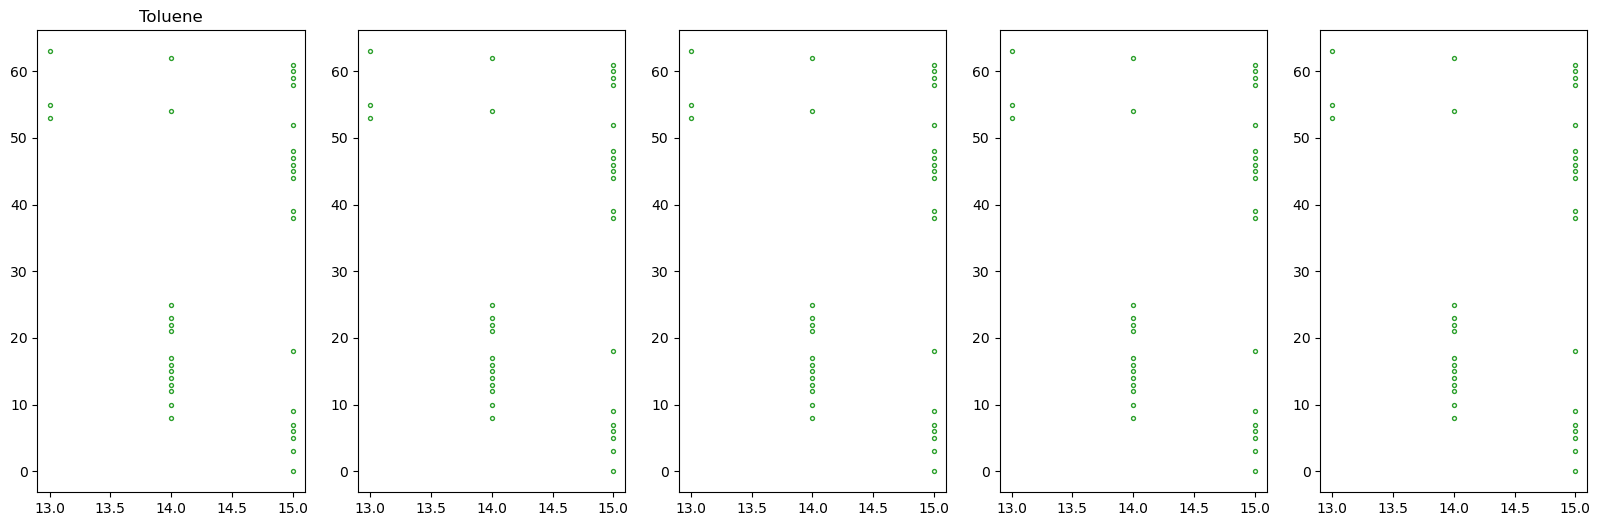

In [7]:
def gammaLearning(gammaCode, epoch, nMCs, plotTitles, nGamma = 5, figsize = (6,20)): 
    color = ['k','b', 'g', 'r', 'y', 'm', 'c','b', 'g', 'r', 'C2', 'C3']
    plt.figure(epoch,figsize)
    alignment = '15' #'15' means 1 row 5 columns and pairs with figsize (20,6)
    #print(str(correlating_digit) + color[epoch-1]) #plt.title(epoch)
    for i in range(0, nGamma):
        s = int(alignment+str(i+1))
        plt.subplot(s);
        if(i==0):
            if epoch == 1:
                plt.title(str(0))
            else:
                plt.title(str(plotTitles[epoch-2]))
        for j in range(0, nMCs):
            #Learned Toluene
            gammaID = epoch*nGamma + i; 
            if gammaCode[gammaID][j] != 0:
                spikeTime = 20 - gammaCode[gammaID][j]; 
                #plt.scatter(spikeTime, j, s= 8, marker = 'o', color = 'w', edgecolor='k')
                plt.scatter(spikeTime, j, s= 8, marker = 'o', color = 'w', edgecolor=color[epoch-1])

plotTitles = ['Acetaldehyde', 'Acetone', 'Ammonia', 'Benzene', 'Butanol', 'Carbon Monoxide', 'Ethylene', 'Methane', 'Methanol', 'Toluene'];
for epoch in range(1,12):
    gammaLearning(epl.gammaCode, epoch, epl.nMCs, plotTitles,nGamma=5, figsize = (20,6))


# my_plotFigure4a experimentation

In [8]:
(len(epl.gammaCode), len(epl.gammaCode[1]))

(600, 72)

In [9]:
sum(epl.gammaCode, []); #way of flattening list

In [10]:
indices = [i for i, x in enumerate(sum(epl.gammaCode, [])) if x == 0]
indices[:] = [x / nMCs for x in indices]

In [11]:
def my_plotFigure4a(gammaCode, nMCs = 72, nGamma = 5): 
    plt.figure(1, figsize=(6, 20))
    plt.title("My Figure 4a")
    
    for i in range(0, nGamma):
        
        #formatting
        s = int('42'+str(i+1)) #4 columns and 2 rows
        plt.subplot(s);
        plt.title("My Figure 4a " + str(i+1))
        
        #
        for j in range(0, nMCs):
            
            #Learned Toluene they have: 9 
            # i want: 54
            #gammaID = 0*nGamma + 9; 
            gammaID = 50+ nGamma*1 -1 
            if gammaCode[gammaID][j] != 0:
                spikeTime = 20 - gammaCode[gammaID][j]; 
                plt.scatter(spikeTime, j, s= 8, marker = 'o', color = 'w', edgecolor=(0, 0, 1, 1))
            
            #Learned Acetone 50+9 59
            #i want: 79
            #gammaID = 5*5*2 + 9;       #Acetone is odor # 6
            gammaID = 50 + 6*nGamma - 1
            if gammaCode[gammaID][j] != 0: 
                spikeTime = 20 - gammaCode[gammaID][j]; 
                plt.scatter(spikeTime, j, s= 8, marker = 'o', color = 'w', edgecolor=(1, 0, 0, 0.25))
            
            #Occluded Toluene 100, 101, 102, 103, 104
            gammaID = 100 + i; 
            if gammaCode[gammaID][j] != 0:
                spikeTime = 20 - gammaCode[gammaID][j]; 
                plt.scatter(spikeTime, j, s= 2, marker = 'o', color = 'k'); 
           
        
            plt.ylim([-2,nMCs])
            offset = 40*i; 
            plt.xticks([0, 4, 8, 12, 16, 20], [offset+0, offset+4, offset+8, offset+12, offset+16, offset+20]); 
            plt.yticks(range(int(nMCs/4), nMCs+1, int(nMCs/4))); 
    plt.xlabel('Timesteps');
    plt.ylabel('MC Index');  
    

    plt.show(); 

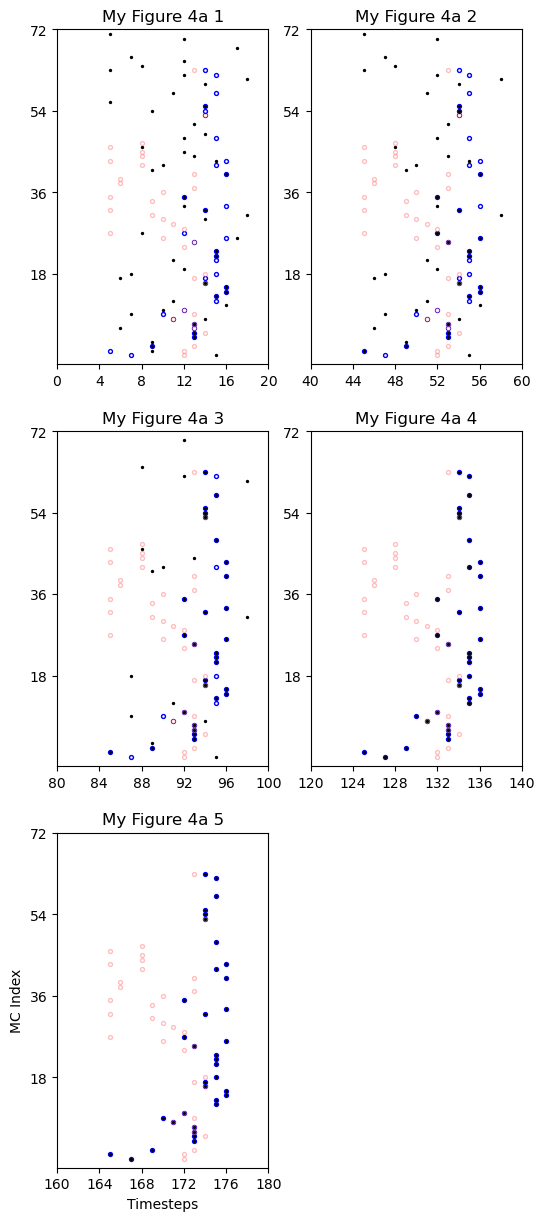

In [12]:
my_plotFigure4a(epl.gammaCode, nMCs = nMCs, nGamma = nGammaPerOdor)

# parsing of epl.gammaCode

In [13]:
ignore = epl.gammaCode[:50]
templates = epl.gammaCode[50:100]
testing = epl.gammaCode[100:]

Reformat in 3D arrays

In [14]:
templatess = templates[4::5]

In [15]:
testingg = []
for x in range(0, len(testing), 5):
    testingg.append(testing[x+4])

# my_Figure 5i

add ypoints to readout code

In [16]:
ypoints = [1]
templateID = 0
"""
10 is the number of occluded version of any given odor in testing (along levels of occlusion)
"""
for i in range(0,10):
    #ypoints.append(readout.jaccardSimilarity(templatess[0][4], testingg[i][4]))
    ypoints.append(readout.computeSimilarity(templatess[templateID], testingg[templateID*10 + i]))

AttributeError: 'function' object has no attribute 'computeSimilarity'

In [ ]:
xpoints = np.linspace(0,1,11)
ypoints = np.array(ypoints)


plt.plot(xpoints, ypoints, 's',ls = '--', c = 'g')
#plt.plot([0,xpoints[-1]], [.75, .75])
plt.xlabel('Proportion occluded')
plt.ylabel('similarity')
plt.title('Figure 5i')
plt.show()

## Now, I want to make a decision matrix

In [ ]:
# jaccardSimilarity(trained[-1,i], tested[-1,j])
# i is the consecutive original digit. j is the consecutive test digit
# make an array from nested loop
def jaccardSimilarity(l1=[], l2=[]):
    """ computes Jaccard similarity"""
    list1 = []
    list2 = []
    for i in range(0, len(l1)):
        list1.append((i, l1[i]))
        list2.append((i, l2[i]))
    set1 = set(list1)
    set2 = set(list2)
    intersectionSize = len(set.intersection(set1, set2))
    unionSize = len(set.union(set1, set2))
    # print intersectionSize, unionSize;
    return round(intersectionSize/float(unionSize), 4)
def computeSimilarity(l1, l2):
    """ computes similarity index """
    return jaccardSimilarity(l1, l2)

In [ ]:
SImatrix = np.zeros((len(trainingOdors[0]), len(testOdors[0])), dtype =float)  
for i in range(0, len(trainingOdors[-1])):
    for j in range(0, len(testOdors[-1])):
        SImatrix[i][j] = (computeSimilarity(trainingOdors[-1][i], testOdors[-1][j]))


decisionMatrix = (SImatrix> 0.75)

truthMatrix = np.equal(digits.T, test_digits)
truthMatrix.shape
#digits which is a 2d array, use reshape to 
#operations broadcasting when comparing two arrays of different dimensions

#this is not decisionMatrix xor truthMatrix
#returns all the places where the decision is correct (trues are trues and falses re false)
#take a look at this logic
# Try this alternative expression: correct = not (decisionMatrix xor truthMatrix)
correct = ~(decisionMatrix ^ truthMatrix)

correctID = np.count_nonzero(correct)
per_correct = float(correctID)/SImatrix.size *100

correctness.append(per_correct)

In [ ]:
import numpy as np
import time

class HashTableClassifier():
    def train(self, training_data):
        self.learned_odour_representations = {idx: odour for idx, odour in enumerate(training_data)}

    def denoise_test(self, testing_data):
        self.denoised_testing_data = {}
        for idx_test, testing_odour in enumerate(testing_data):
            best_matching, idx_best_matching = 0, None
            for idx_train, training_odour in self.learned_odour_representations.items():
                matches = sum(training_odour == testing_odour)
                if best_matching < matches:
                    best_matching, idx_best_matching = matches, idx_train
            self.denoised_testing_data[idx_test] = self.learned_odour_representations[idx_best_matching]

    def get_similarity_matrix(self):
        sMatrix = np.zeros((len(self.denoised_testing_data) * 5, len(self.learned_odour_representations)))
        for idx_test, testing_odour in self.denoised_testing_data.items():
            for idx_train, training_odour in self.learned_odour_representations.items():
                similarity = np.count_nonzero(training_odour == testing_odour) / 72
                for i in range(5):
                    sMatrix[5 * idx_test + i, idx_train] = similarity
        return sMatrix


def run_from_arrays(trainingOdors, testOdors):
    nOdors = len(trainingOdors)
    nTestPerOdor = len(testOdors) / nOdors
    print("Number of odors to train:", len(trainingOdors))
    print("Number of odors to test:", len(testOdors))

    # Initiate classifier
    hashtable_classifier = HashTableClassifier()

    # Run training
    t0 = time.time()
    hashtable_classifier.train(trainingOdors)
    t1 = time.time()

    # Run testing
    hashtable_classifier.denoise_test(testOdors)
    t2 = time.time()

    train_time = t1 - t0
    test_time = t2 - t1

    print("Training Duration total:", train_time, "s")
    print("Testing Duration total:", test_time, "s")

    # Extract similarity matrix
    sMatrix = hashtable_classifier.get_similarity_matrix()
    return sMatrix, hashtable_classifier.denoised_testing_data

sMatrix, denoised_data = run_from_arrays(trainingOdors, testOdors)
print(sMatrix.shape)  # Check the shape of the similarity matrix
plots.plotFigure4b(sMatrix); 
plots.plotFigure4d(epl.gammaCode, sMatrix); 